In [110]:
import os
os.environ["DDE_BACKEND"] = "tensorflow"
os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [111]:
import deepxde as dde
#dde.config.set_default_autodiff("zcs")
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [3]:
spatial_geom = dde.geometry.Rectangle([0.0, 0.0], [1.0, 1.0])
timedomain = dde.geometry.TimeDomain(0.0, 1.0)
geom = dde.geometry.GeometryXTime(spatial_geom, timedomain)

In [113]:
#Cylindrical domain
circle = dde.geometry.Disk([0.0, 0.5], 0.5)
rectangle = dde.geometry.Rectangle([0.0, 0.0], [1.0, 1.0])
spatial_geom_cyl = dde.geometry.CSGDifference(rectangle, circle)
timedom = dde.geometry.TimeDomain(0.0, 1.0)
geom_cyl = dde.geometry.GeometryXTime(spatial_geom_cyl, timedom)

THE nu in the equation can either be a trainable parameter and be passed as a dde.Variable or it can be a variable parameter set during inference(part of the inputs).

In [4]:
pho = 1

In [38]:
def Navier_stokes(x, y, z):
    trunk_coords = x

    u = y[:, 0:1]
    v = y[:, 1:2]
    p = y[:, 2:3]

    nu = 0.1

    #continuity equation
    du_dx = dde.grad.jacobian(u, trunk_coords, i=0, j=0)
    dv_dy = dde.grad.jacobian(v, trunk_coords, i=0, j=1)
    continuity = du_dx + dv_dy

    #x-momentum equation
    du_dt = dde.grad.jacobian(u, trunk_coords, i=0, j=2)
    du_dy = dde.grad.jacobian(u, trunk_coords, i=0, j=1)
    dp_dx = dde.grad.jacobian(p, trunk_coords, i=0, j=0)
    du_xx = dde.grad.hessian(u, trunk_coords, component=0, i=0, j=0)
    du_yy = dde.grad.hessian(u, trunk_coords, component=0, i=1, j=1)
    x_mom = du_dt + u*du_dx + v*du_dy + (1/pho)*dp_dx - nu*(du_xx + du_yy)

    #y-momentum equation
    dv_dt = dde.grad.jacobian(v, trunk_coords, i=0, j=2)
    dv_dy = dde.grad.jacobian(v, trunk_coords, i=0, j=1)
    dp_dy = dde.grad.jacobian(p, trunk_coords, i=0, j=1)
    dv_xx = dde.grad.hessian(v, trunk_coords, component=0, i=0, j=0)
    dv_yy = dde.grad.hessian(v, trunk_coords, component=0, i=1, j=1)
    dv_dx = dde.grad.jacobian(v, trunk_coords, i=0, j=0)
    y_mom = dv_dt + u*dv_dx + v*dv_dy + (1/pho)*dp_dy - nu*(dv_xx + dv_yy)

    return [continuity, x_mom, y_mom]

#enforce the stream function using an output_transform


In [40]:
#Enforicing the stream function psi here to satisfy the continuity automatically(not being used rn)

def output_transform(inputs, outputs):
    trunk_inputs = inputs[1]
    x = trunk_inputs[:, 0:1]
    y = trunk_inputs[:, 1:2]
    t = trunk_inputs[:, 2:3]

    psi = outputs[:, 0:1]
    p = outputs[:, 1:2]

    psi = x * (1 - x) * y * (1 - y) * psi #hard boundary(enforcing 0.0 output at x = 0.0, y=0.0)

    u = dde.grad.jacobian(psi, trunk_inputs, i=0, j=1)
    v = - dde.grad.jacobian(psi, trunk_inputs, i=0, j=0)

    return tf.concat([u, v, p], axis=1)


In [41]:
#enforcing Pin and Pout through hard boundary conditions

def output_transform_p(inputs, outputs):
    branch_inputs = inputs[0]
    trunk_inputs = inputs[1]

    x = trunk_inputs[:, 0:1]
    y = trunk_inputs[:, 1:2]
    t = trunk_inputs[:, 2:3]

    Pin = branch_inputs[:, 0:1]
    Pout = branch_inputs[:, 1:2]

    u = outputs[:, 0:1]
    v = outputs[:, 1:2]
    p_hat = outputs[:, 2:3]

    p = (1.0 - x) * Pin + x*Pout + x*(1.0 - x)*p_hat

    return tf.concat([u, v, p], axis=1)

In [42]:
def is_on_right_boundary(X, on_boundary):
    if not on_boundary:
        return False

    return dde.utils.isclose(X[0], 1.0)

def is_on_wall(X, on_boundary):
    if not on_boundary:
        return False

    return dde.utils.isclose(X[1], 0.0) or dde.utils.isclose(X[1], 1.0)

def wall_condition(X):
    return 0.0

In [43]:
#Initial condition
def is_initial(X, is_initial):
    if not is_initial:
        return False

    return dde.utils.isclose(X[2], 0.0)

def initial_value(X):
    return 0.0

In [44]:
bc_u = dde.icbc.DirichletBC(geom, wall_condition, is_on_wall, component=0)
bc_v = dde.icbc.DirichletBC(geom, wall_condition, is_on_wall, component=1)
ic_u = dde.icbc.IC(geom, initial_value, is_initial, component=0)
ic_v = dde.icbc.IC(geom, initial_value, is_initial, component=1)

In [80]:
data = dde.data.TimePDE(
    geom,
    Navier_stokes,
    [bc_u, bc_v, ic_u, ic_v],
    num_domain=500,
    num_boundary=100,
    num_test=300,
    num_initial=100,
    train_distribution="pseudo"
)

In [ ]:
data_ic_test = dde.data.TimePDE(
    geom,
    Navier_stokes,
    [ic_u, ic_v],
    num_domain=500,
    num_boundary=100,
    num_test=300,
    num_initial=100
    train_distribution="pseudo"
)

In [58]:
for i, bc in enumerate(data.bcs):
    print(i, type(bc).__name__)

0 DirichletBC
1 DirichletBC
2 IC
3 IC


DEFINING THE OPERATOR AND FUNCTION SPACE

In [81]:
tf.experimental.numpy.experimental_enable_numpy_behavior()
class ConstantFuncSpace(dde.data.function_spaces.FunctionSpace):
    def __init__(self, low, high):
        self.low = low
        self.high = high

    def random(self, size):
        #returning [Pin, Pout]
        pin = np.random.uniform(self.low, self.high, size=(size, 1))
        pout = np.random.uniform(0.0, self.low - 0.1, size = (size, 1))
        return np.hstack([pin, pout])

    def eval_one(self, feature, x):
        return feature

    def eval_batch(self, features, xs):
        return features

In [82]:
#Defining the function space
func_space = ConstantFuncSpace(low=0.5, high=2.0)

n_sensors = 2

eval_points = np.linspace(0, 1.0, n_sensors)[:, None]


In [83]:
pde_op = dde.data.PDEOperator(
    pde=data,
    function_space=func_space,
    evaluation_points=eval_points,
    num_function=5, #No of [Pin, Pout] to sample per training step
    num_test=300,
)

In [84]:
print(pde_op.train_x[0].shape)
print(pde_op.train_x[1].shape)

(4960, 2)
(4960, 3)


In [85]:
#Model definition
n_sensors = 2

net = dde.nn.DeepONet(
    [n_sensors]+[96]*2, # n_sensors + pin, l and d(dimensions of the pipe)
    [3]+[96]*2,
    "tanh",
    "Glorot normal",
    num_outputs=3,
    multi_output_strategy="split_both"
)
net.apply_output_transform(output_transform_p)

In [86]:
model = dde.Model(pde_op, net)

model.compile("adam", lr=0.001)

Compiling model...
'compile' took 0.002854 s



In [87]:
branch_inputs = np.array([
    [2.0, 0.4],
    [1.5, 0.3],
    [1.0, 0.2],
    [0.5, 0.1]
])

trunk_inputs = np.array([
    [0.5, 0.5, 0.0],
    [0.8, 0.2, 0.0],
    [0.0, 0.0, 0.0],
    [0.9, 0.9, 0.0]
])

preds = model.predict((branch_inputs, trunk_inputs))

print(preds)

/media/srimukha-sarma/Windows-SSD/conda-envs/deepxde/lib/python3.11/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


[[0.94582254 0.66884303 1.36603   ]
 [0.83575207 0.80417925 0.65232146]
 [0.         0.         1.        ]
 [0.43861768 0.30874968 0.16749434]]


In [88]:
early_stop = dde.callbacks.EarlyStopping(patience=5)
out_dir = "pino_models_no_stream_func"
os.makedirs(out_dir, exist_ok=True)
ckpt = dde.callbacks.ModelCheckpoint(out_dir)

In [89]:
resampler = dde.callbacks.PDEPointResampler(period=1000)

Training model...

Step      Train loss                                                                Test loss                                                                 Test metric
1         [3.61e-01, 7.47e-01, 1.16e-01, 3.38e-01, 1.23e-01, 3.46e-01, 2.06e-01]    [2.89e-01, 5.11e-01, 6.10e-02, 3.38e-01, 1.23e-01, 3.46e-01, 2.06e-01]    []  
Epoch 7: early stopping

Best model at step 1:
  train loss: 2.24e+00
  test loss: 1.88e+00
  test metric: []

'train' took 1.800623 s

Saving loss history to pino_01_no_stream/loss.dat ...
Error: The network has multiple inputs, and saving such result han't been implemented.
Error: The network has multiple inputs, and plotting such result han't been implemented.


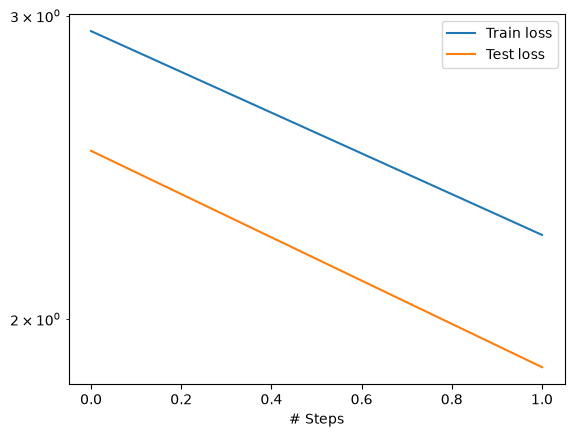

In [ ]:
losshistory, train_state = model.train(iterations=15000, callbacks=[early_stop], disregard_previous_best=True,
                                       display_every=500)
dir = "pino_01_no_stream"
os.makedirs(dir, exist_ok=True)
dde.saveplot(losshistory, train_state, issave=True, isplot=False, output_dir=dir)

Compiling model...
'compile' took 0.050617 s

Training model...

Step      Train loss                                                                Test loss                                                                 Test metric
7         [3.52e-03, 4.90e-01, 3.57e-02, 2.46e-01, 8.11e-02, 7.03e-02, 5.16e-02]    [5.37e-03, 3.56e-01, 2.25e-02, 2.46e-01, 8.11e-02, 7.03e-02, 5.16e-02]    []  
1596      [3.83e-06, 5.44e-05, 3.86e-06, 1.91e-04, 1.83e-06, 3.08e-04, 5.88e-07]    [3.12e-06, 1.84e-04, 1.17e-05, 1.91e-04, 1.83e-06, 3.08e-04, 5.88e-07]    []  

Best model at step 1596:
  train loss: 5.63e-04
  test loss: 7.00e-04
  test metric: []

'train' took 691.576343 s

Saving loss history to pino_01_no_stream_finetuned/loss.dat ...
Error: The network has multiple inputs, and saving such result han't been implemented.
Error: The network has multiple inputs, and plotting such result han't been implemented.


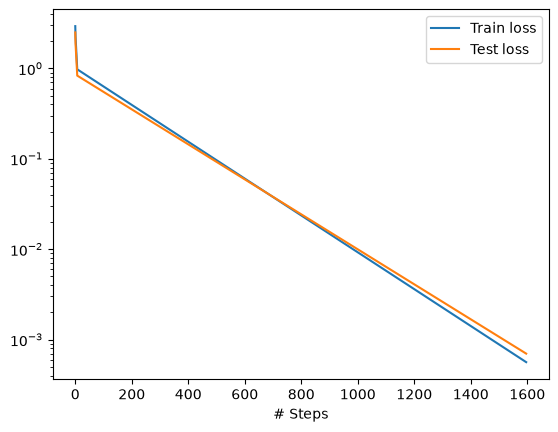

In [92]:
dde.optimizers.config.set_LBFGS_options(maxiter=15000)
model.compile("L-BFGS")
losshistory, train_state = model.train(callbacks=[ckpt], disregard_previous_best=True, display_every=1000)

dir = "pino_01_no_stream_finetuned"
os.makedirs(dir, exist_ok=True)
dde.saveplot(losshistory, train_state, issave=True, isplot=True, output_dir=dir)

In [93]:
output_dir = "pino_models_no_stream"
os.makedirs(output_dir, exist_ok=True)
model.save(os.path.join(output_dir, "pino_model_no_stream"), protocol="backend", verbose=0)

'pino_models_no_stream/pino_model_no_stream-1596.weights.h5'

EVAL

In [ ]:
test_x = np.random.uniform(0.0, 1.0, (1000, 1))
test_y = np.random.uniform(0.0, 1.0, (1000, 1))
test_t = np.random.uniform(0.0, 1.0, (1000, 1))
test_xyt_trunk = np.hstack([test_x, test_y, test_t])

n_sensors = 2
branch_func = np.random.uniform(0.0, 2.0, (1, n_sensors))
branch_net = np.tile(branch_func, (1000, 1))

residuals = model.predict((branch_net, test_xyt_trunk))

print(residuals)


[[-0.03580517 -0.01351693  0.26590833]
 [ 0.01896696 -0.00713297  0.25796223]
 [-0.02818404 -0.00762812  0.25709102]
 ...
 [-0.01701368 -0.00862279  0.25904766]
 [-0.01112056 -0.00634867  0.2646352 ]
 [-0.03433345 -0.0119586   0.25693214]]


In [ ]:
#checking outputs on random points

test_pts = np.array([
    [0.05, 0.5, 0.5], [0.15, 0.5, 0.5], [0.20, 0.5, 0.5], [0.25, 0.5, 0.5], [0.30, 0.5, 0.5], [0.35, 0.5, 0.5], [0.45, 0.5, 0.5],
    [0.55, 0.5, 0.5], [0.65, 0.5, 0.5], [0.75, 0.5, 0.5], [0.85, 0.5, 0.5], [0.95, 0.5, 0.5]
])

n_sensors = 2
branch_func = np.random.uniform(0.0, 1.0, (1, n_sensors))
branch_net = np.tile(branch_func, (len(test_pts), 1))

# Evaluate the PDE operator
outputs = model.predict((branch_net,test_pts))
sum_u_vel = 0
sum_v_vel = 0
sum_p = 0
for output in outputs:
    print(f"u vel: {output[0]}, v vel: {output[1]}, pressure: {output[2]}")
    sum_u_vel += output[0]
    sum_v_vel += output[1]
    sum_p += output[2]



mean_u_vel_centre = sum_u_vel / len(test_pts)
mean_v_vel_centre = sum_v_vel / len(test_pts)
mean_p_centre = sum_p / len(test_pts)
print(mean_u_vel_centre, mean_v_vel_centre, mean_p_centre)

u vel: 0.06663686037063599, v vel: 0.3206380605697632, pressure: 0.33363330364227295
u vel: 0.09658753871917725, v vel: 0.05835016071796417, pressure: 0.18378573656082153
u vel: 0.08934140205383301, v vel: -0.0201176255941391, pressure: 0.14021074771881104
u vel: 0.07794082164764404, v vel: -0.06770338118076324, pressure: 0.11031663417816162
u vel: 0.06617915630340576, v vel: -0.09137329459190369, pressure: 0.09006726741790771
u vel: 0.0558544397354126, v vel: -0.09821122139692307, pressure: 0.07633042335510254
u vel: 0.04130852222442627, v vel: -0.08424051851034164, pressure: 0.059821728616952896
u vel: 0.033353984355926514, v vel: -0.05821142718195915, pressure: 0.04898485913872719
u vel: 0.028801441192626953, v vel: -0.03581365570425987, pressure: 0.03802657499909401
u vel: 0.02506318688392639, v vel: -0.022740626707673073, pressure: 0.024318041279911995
u vel: 0.01985308527946472, v vel: -0.017420660704374313, pressure: 0.006848047021776438
u vel: 0.009382128715515137, v vel: -0.01

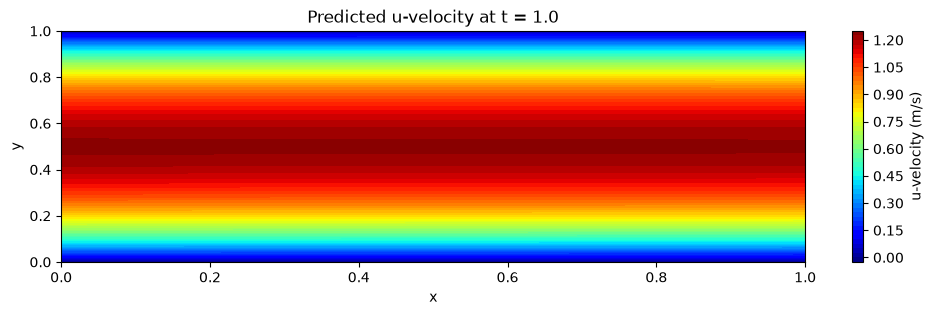

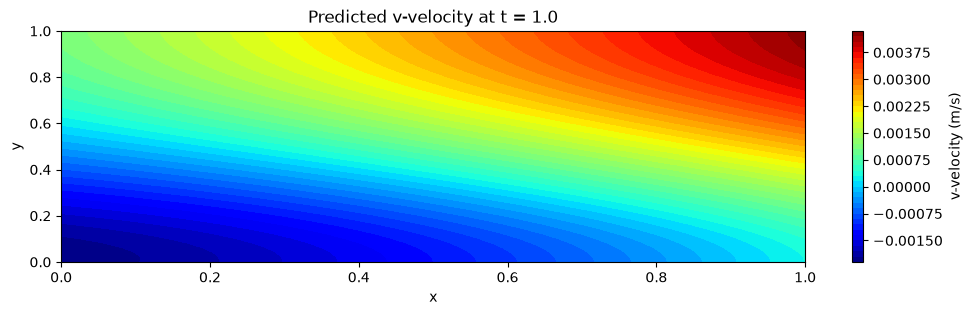

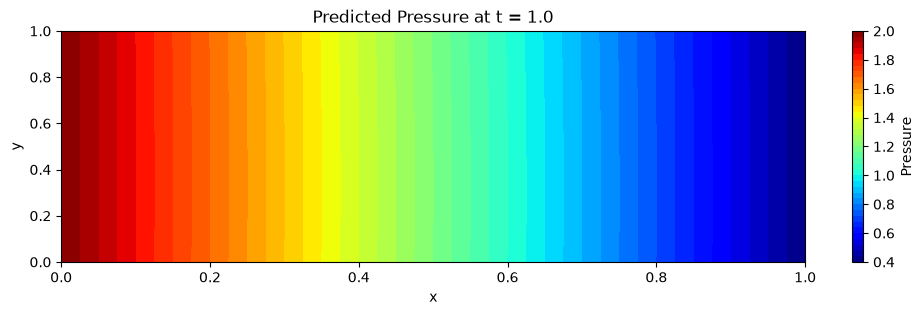

In [108]:
#Plotting the fluid flow
n_sensors = 2
branch_func = np.array([[2.0, 0.4]])
branch_net = np.tile(branch_func, (10000, 1))

x_grid = np.linspace(0.0, 1.0, 200)
y_grid = np.linspace(0.0, 1.0, 50)

X, Y = np.meshgrid(x_grid, y_grid)

T = np.full_like(X, 1.0)


grid_xyt = np.vstack((X.flatten(), Y.flatten(), T.flatten())).T
pred_grid = model.predict((branch_net ,grid_xyt))

U_pred = pred_grid[:, 0].reshape(X.shape)
V_pred = pred_grid[:, 1].reshape(X.shape)
P_pred = pred_grid[:, 2].reshape(X.shape)

# 4. Plot U-Velocity Heatmap
plt.figure(figsize=(12, 3))
plt.contourf(X, Y, U_pred, levels=50, cmap='jet')
plt.colorbar(label='u-velocity (m/s)')
plt.title('Predicted u-velocity at t = 1.0')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# 5. Plot V-Velocity Heatmap
plt.figure(figsize=(12, 3))
plt.contourf(X, Y, V_pred, levels=50, cmap='jet')
plt.colorbar(label='v-velocity (m/s)')
plt.title('Predicted v-velocity at t = 1.0')
plt.xlabel('x')
plt.ylabel('y')
plt.show() 

# 6. Plot Pressure Heatmap
plt.figure(figsize=(12, 3))
plt.contourf(X, Y, P_pred, levels=50, cmap='jet')
plt.colorbar(label='Pressure')
plt.title('Predicted Pressure at t = 1.0')
plt.xlabel('x')
plt.ylabel('y')
plt.show()



In [102]:
test_pts = np.array([
    [0.25, 0.5, 0.5],
    [0.50, 0.5, 0.5],
    [0.75, 0.5, 0.5],
])

branches = [
    np.array([2.0, 0.4]),
    np.array([1.5, 0.3]),
    np.array([1.0, 0.2]),
]

for branch in branches:

    branch_net = np.tile(
        branch,
        (len(test_pts), 1)
    )

    pred = model.predict(
        (branch_net, test_pts)
    )

    print("\nPin, Pout =", branch)
    print(pred)


Pin, Pout = [2.  0.4]
[[ 7.2971463e-01 -8.5130800e-05  1.6004063e+00]
 [ 7.3028827e-01  6.0132006e-04  1.2005509e+00]
 [ 7.3108733e-01  1.3263025e-03  8.0033970e-01]]

Pin, Pout = [1.5 0.3]
[[ 5.6309348e-01 -1.8699840e-04  1.2002608e+00]
 [ 5.6348586e-01 -6.9582229e-04  9.0032107e-01]
 [ 5.6406546e-01 -1.1664717e-03  6.0016334e-01]]

Pin, Pout = [1.  0.2]
[[ 0.380103   -0.00128208  0.80029905]
 [ 0.38015682 -0.0022715   0.6004713 ]
 [ 0.3803479  -0.0032263   0.4003799 ]]


In [103]:
Pin = 2.0
Pout = 0.4

y_vals = np.linspace(0, 1, 21)

test_pts = np.column_stack([
    np.full_like(y_vals, 0.5),
    y_vals,
    np.full_like(y_vals, 1.0)
])

branch = np.tile(
    np.array([Pin, Pout]),
    (len(test_pts), 1)
)

pred = model.predict((branch, test_pts))

u = pred[:, 0]
v = pred[:, 1]
p = pred[:, 2]

for y, ui, vi, pi in zip(y_vals, u, v, p):
    print(f"y={y:.2f}, u={ui:.5f}, v={vi:.5f}, p={pi:.5f}")

y=0.00, u=-0.00817, v=-0.00120, p=1.19835
y=0.05, u=0.25808, v=-0.00117, p=1.19884
y=0.10, u=0.48452, v=-0.00107, p=1.19924
y=0.15, u=0.67459, v=-0.00091, p=1.19953
y=0.20, u=0.83173, v=-0.00071, p=1.19975
y=0.25, u=0.95908, v=-0.00047, p=1.19987
y=0.30, u=1.05942, v=-0.00020, p=1.19992
y=0.35, u=1.13504, v=0.00008, p=1.19990
y=0.40, u=1.18775, v=0.00038, p=1.19982
y=0.45, u=1.21881, v=0.00067, p=1.19969
y=0.50, u=1.22896, v=0.00097, p=1.19950
y=0.55, u=1.21843, v=0.00125, p=1.19928
y=0.60, u=1.18696, v=0.00151, p=1.19902
y=0.65, u=1.13380, v=0.00175, p=1.19873
y=0.70, u=1.05777, v=0.00197, p=1.19841
y=0.75, u=0.95727, v=0.00217, p=1.19806
y=0.80, u=0.83036, v=0.00233, p=1.19767
y=0.85, u=0.67481, v=0.00247, p=1.19725
y=0.90, u=0.48820, v=0.00258, p=1.19677
y=0.95, u=0.26805, v=0.00266, p=1.19622
y=1.00, u=0.01182, v=0.00270, p=1.19559


In [104]:
times = [0.0, 0.25, 0.5, 1.0]

Pin = 2.0
Pout = 0.4

y_vals = np.linspace(0, 1, 51)

for t in times:

    test_pts = np.column_stack([
        np.full_like(y_vals, 0.5),
        y_vals,
        np.full_like(y_vals, t)
    ])

    branch = np.tile(
        np.array([Pin, Pout]),
        (len(test_pts), 1)
    )

    pred = model.predict((branch, test_pts))

    u = pred[:, 0]

    print(
        f"t={t:.2f}, "
        f"umax={np.max(u):.5f}, "
        f"u_wall=({u[0]:.5f}, {u[-1]:.5f})"
    )

t=0.00, umax=0.03381, u_wall=(-0.05281, -0.05901)
t=0.25, umax=0.38411, u_wall=(0.00832, 0.00664)
t=0.50, umax=0.73029, u_wall=(0.02569, 0.01912)
t=1.00, umax=1.22896, u_wall=(-0.00817, 0.01182)


In [109]:
v_abs = np.abs(V_pred)

print("max |v| =", np.max(v_abs))
print("mean |v| =", np.mean(v_abs))
print("RMS v    =", np.sqrt(np.mean(V_pred**2)))

print("max |u| =", np.max(np.abs(U_pred)))
print("v/u ratio =", np.max(np.abs(V_pred)) / np.max(np.abs(U_pred)))

max |v| = 0.0042670495
mean |v| = 0.0014833211
RMS v    = 0.0018101283
max |u| = 1.2296022
v/u ratio = 0.003470268
